In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

In [15]:
def preprocess_data(data):
    df= data.copy()

    df.drop(columns=['SampleID'], inplace= True)

    return df

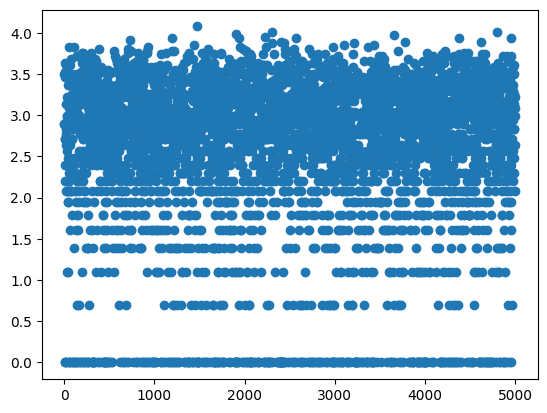

In [16]:
train_df= pd.read_csv("train.csv")
test_df= pd.read_csv("test.csv")

X_train= preprocess_data(train_df.drop(columns=['delay_minutes']))
y_train= np.log1p(train_df['delay_minutes'])

X_test= preprocess_data(test_df)

plt.scatter(train_df['SampleID'], y_train)
plt.show()

In [17]:
from catboost import CatBoostRegressor

cat_cols= X_train.select_dtypes(include=['object', 'str']).columns.to_list()

model= CatBoostRegressor(
    iterations= 3000,
    learning_rate= 0.03,
    depth=6,
    cat_features= cat_cols,
    early_stopping_rounds= 200,
    random_state= seed
)

model.fit(X_train, y_train, verbose= 200)

predictions= np.expm1(model.predict(X_test))

0:	learn: 0.9533410	total: 3.54ms	remaining: 10.6s
200:	learn: 0.4881526	total: 655ms	remaining: 9.12s
400:	learn: 0.4624985	total: 1.31s	remaining: 8.51s
600:	learn: 0.4427214	total: 1.99s	remaining: 7.97s
800:	learn: 0.4270823	total: 2.62s	remaining: 7.22s
1000:	learn: 0.4124701	total: 3.37s	remaining: 6.75s
1200:	learn: 0.3997459	total: 4.01s	remaining: 6.02s
1400:	learn: 0.3873174	total: 4.63s	remaining: 5.29s
1600:	learn: 0.3746523	total: 5.28s	remaining: 4.62s
1800:	learn: 0.3637560	total: 5.91s	remaining: 3.94s
2000:	learn: 0.3525268	total: 6.55s	remaining: 3.28s
2200:	learn: 0.3422310	total: 7.11s	remaining: 2.59s
2400:	learn: 0.3322101	total: 7.69s	remaining: 1.92s
2600:	learn: 0.3229573	total: 8.32s	remaining: 1.28s
2800:	learn: 0.3149383	total: 8.92s	remaining: 635ms
2999:	learn: 0.3065113	total: 9.46s	remaining: 0us


In [23]:
answer= pd.DataFrame({
    'SampleID': test_df['SampleID'],
    'delay_minutes': predictions.astype(int)
})

answer.head()

,SampleID,delay_minutes
0,1501,26
1,2586,5
2,2653,0
3,1055,14
4,705,4


In [24]:
answer.to_csv("submission.csv", index= False)